In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [3]:
# Understand the dataset
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
df.shape

(1000, 9)

In [6]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [7]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

In [13]:
# Average Order Value
aov = df['Total Amount'].mean()
print(f"Average Order Value: ₹{aov:.2f}")

# More useful breakdowns:
print("\nAOV by Product Category:")
print(df.groupby('Product Category')['Total Amount'].mean())

print("\nAOV by Gender:")
print(df.groupby('Gender')['Total Amount'].mean())

Average Order Value: ₹456.00

AOV by Product Category:
Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64

AOV by Gender:
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


## Chart 1: Which category makes most money?

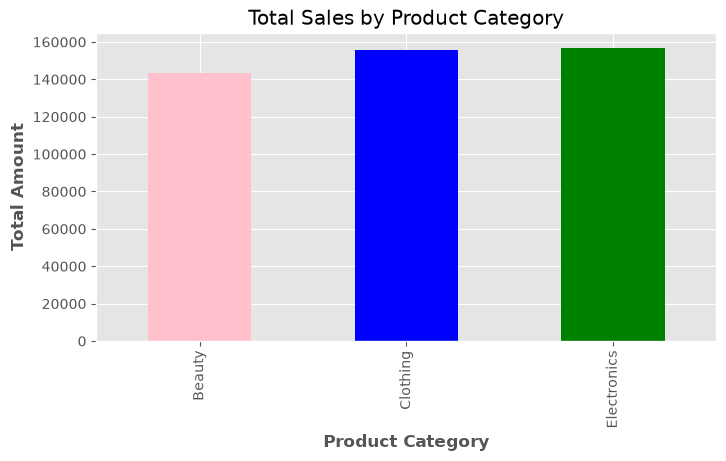

In [14]:
plt.style.use("ggplot") # makes charts look better

plt.figure(figsize=(8,4))
df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar" , color=["pink","blue","green"])
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category", fontweight="bold")
plt.ylabel("Total Amount", fontweight="bold")
plt.savefig("total_sales_by_prod_bar.png")
plt.show()

## Chart 2: Gender vs Buying

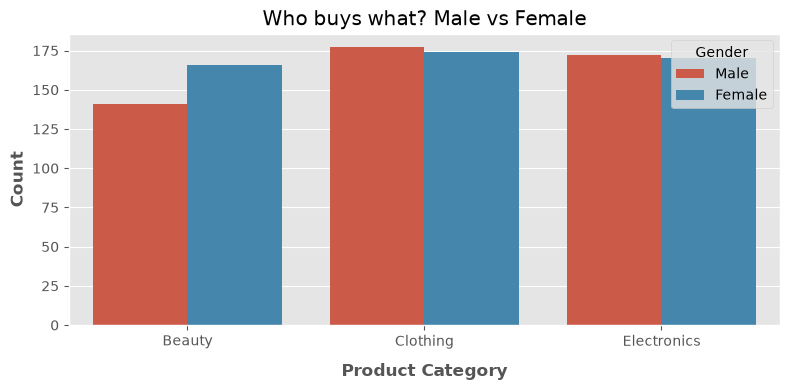

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(x="Product Category", hue="Gender", data=df)
plt.title("Who buys what? Male vs Female")
plt.xlabel("Product Category", fontsize=12, labelpad=10, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("gender_vs_buying.png")
plt.show()

## Chart 3: Age Group Analysis (Very Important)

C:\Users\User\AppData\Local\Temp\ipykernel_3140\3927939375.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Total Amount'].sum().plot(kind='bar')


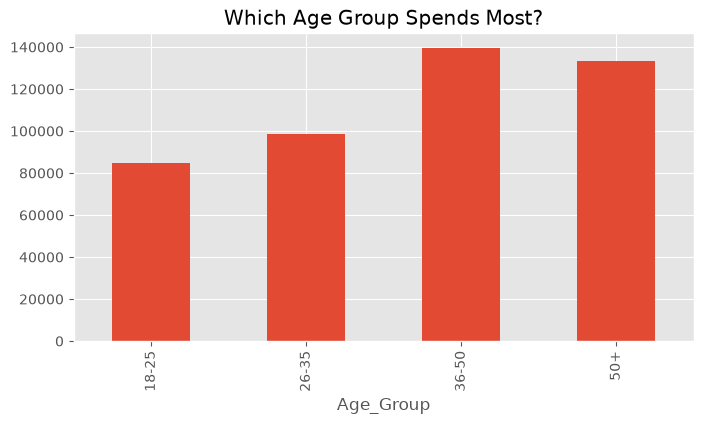

In [16]:
plt.figure(figsize=(8,4))
df['Age_Group'] = pd.cut(df['Age'], bins=[0,25,35,50,70], labels=['18-25','26-35','36-50','50+'])
df.groupby('Age_Group')['Total Amount'].sum().plot(kind='bar')
plt.title('Which Age Group Spends Most?')
plt.savefig("age_group_bar.png")
plt.show()

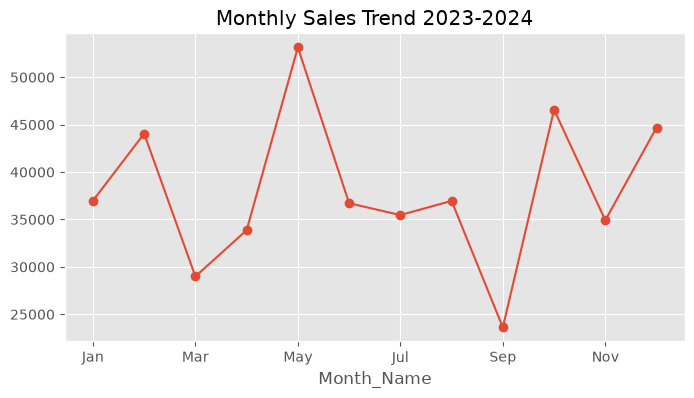

In [17]:
plt.figure(figsize=(8,4))
df.groupby('Month_Name')['Total Amount'].sum().reindex(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']).plot(kind='line', marker='o')
plt.title('Monthly Sales Trend 2023-2024')
plt.savefig("monthly_sales_trend_line.png")
plt.show()

## Chart 5: Price vs Quantity

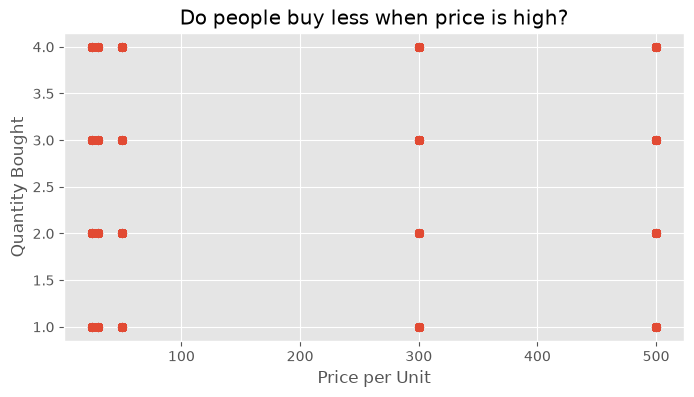

In [18]:
plt.figure(figsize=(8,4))
plt.scatter(df['Price per Unit'], df['Quantity'])
plt.xlabel('Price per Unit')
plt.ylabel('Quantity Bought')
plt.title('Do people buy less when price is high?')
plt.savefig("price_vs_quantity_scatter.png")
plt.show()

# ------------------ KEY INSIGHTS from 1000 Retail Transactions ------------------